<a href="https://colab.research.google.com/github/AnnalisaOri/Progetti/blob/main/binomialtree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The binomial model**

Let us imagine a market with only two periods, \(t=0,1\), representing the present and the future.  
At the future date, only two possible scenarios can occur,
$ ω ∈ {H,T} ≡ Ω $, namely *head* (H) or *tail* (T).

Suppose that, in addition to the bond, there exists only one other asset, called the *stock*.  
Since there are only two assets, we avoid denoting them with the index $ i=0,1 $.  

The bond is risk-free, meaning that its current price is $ 1 $, and its future price is $ e^{r} > 1 $, regardless of the value of $ ω $.  
Note that, under the current assumptions, moving to discounted future quantities amounts to multiplying by  $ e^{-r}$.  

As for the price of the stock — which we denote by $ S $ without subscripts — its evolution can be represented as follows:


$$
S_t =
\begin{cases}
S_0 u, & \text{if } \omega = H, \\
S_0 d, & \text{if } \omega = T.
\end{cases}
$$





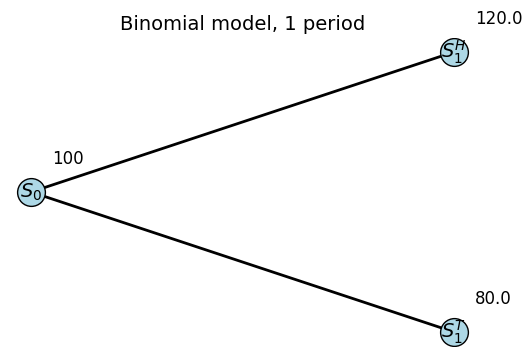

In [5]:
import matplotlib.pyplot as plt

# --- Dati di base ---
S0 = 100   # prezzo iniziale
u = 1.2    # fattore up
d = 0.8    # fattore down

# --- Prezzi futuri ---
S1_up = S0 * u
S1_down = S0 * d

# --- Coordinate per i nodi dell'albero ---
x = [0, 1, 1]
y = [0, 1, -1]
labels = [r"$S_0$", r"$S_1^H$", r"$S_1^T$"]

# --- Connessioni tra i nodi ---
edges = [(0,1), (0,2)]

# --- Disegno dell’albero ---
plt.figure(figsize=(6,4))
for (i,j) in edges:
    plt.plot([x[i], x[j]], [y[i], y[j]], 'k-', lw=2)

for i, label in enumerate(labels):
    plt.scatter(x[i], y[i], s=400, color='lightblue', edgecolor='k', zorder=3)
    plt.text(x[i], y[i], label, fontsize=14, ha='center', va='center')

# --- Aggiungo i valori dei prezzi ---
plt.text(0.05, 0.2, f"{S0}", fontsize=12)
plt.text(1.05, 1.2, f"{S1_up:.1f}", fontsize=12)
plt.text(1.05, -0.8, f"{S1_down:.1f}", fontsize=12)

# --- Pulizia grafico ---
plt.axis('off')
plt.title("Binomial model, 1 period", fontsize=14)
plt.show()





Becuase there is uncertainty, we assume that $ S_1(H) > S_1(T) $ and we write
$
S_1(H) = u S_0 \quad$ and $ \quad S_1(T) = d S_0, $
so that $ u > d $.

We denote by $ \Delta_0 $ the number of units of the stock purchased at time $t = 0 $, and by $ X_0 $ and $ X_1(\omega) $ the wealth held at time $ t = 0 $ and $ t = 1 $ in scenario $ \omega $, respectively.

Note that, by definition, the number of units of the bond is given by
$
X_0 - \Delta_0 S_0 $,
and therefore doe not need to be represented by a separate symbol.

Under these assumptions, the budget constraint obtained takes the simple form:

\begin{equation}
X_1(\omega) = X_0 e^r + \Delta_0 S_0 \left[ \frac{S_1(\omega)}{S_0} - e^r \right] \\
= X_0 e^r + \Delta_0 S_0 \times
\begin{cases}
u - e^r & \text{se } \omega = H,\\
d - e^r & \text{se } \omega = T.
\end{cases}
\end{equation}


If we assume that no arbitrage opportunities exist,
then the following double inequality must hold:

\begin{equation}
u > e^r > d.
\end{equation}

We note that if the double inequality holds, then in the case $ \Delta_0 > 0 $ we have
$ X_1(H) > 0 > X_1(T) $, while in the case $ \Delta_0 < 0 $ we have $ X_1(T) > 0 > X_1(H) $. Thus, whatever the value of $ \Delta_0 $, there are scenarios in which gains occur and others in which losses occur.

Furthermore, by setting:
$
q = \dfrac{e^r - d}{u - d} $,
the following equality must hold:

\begin{equation}
q \frac{S_1(H)}{S_0} + (1 - q) \frac{S_1(T)}{S_0} = e^r,
\end{equation}

that is,

\begin{equation}
S_0 = e^{-r} \left\{ q S_1(H) + (1 - q) S_1(T) \right\}.
\end{equation}

Since $ q, 1 - q > 0 $, the previous quantities can be expressed as expected values —
that is, we can rewrite the equation as follows:

\begin{equation}
e^r = \mathbb{E}^Q \left[ \frac{S_1}{S_0} \right], \quad
S_0 = e^{-r} \mathbb{E}^Q \left[ S_1 \right].
\end{equation}

We observe that the subscript $Q$ indicates that this expected value is computed using the probability measure $Q$ defined by setting $
Q(H) = q \quad \text{and} \quad Q(T) = 1 - q.$

Notice that the first part of~(1.12) establishes that the gross return
$
\dfrac{S_1}{S_0}$
of the risky asset is equal, in expectation, to the gross risk-free return. Since this equality generally characterizes risk-neutral investors, the measure $Q$ is called the $ risk-neutral probability. $

What we have seen so far can therefore be summarized by stating that the market is free of arbitrage opportunities if and only if there exists a risk-neutral probability measure.


# **The replication principle and complete markets**

The risk-neutral probability was obtained by examining exclusively the bond and the stock. Let us then consider an additional financial asset, described by the value $ V_1(\omega)$ that it pays to the investor at time $ t = 1 $ in the two possible scenarios: $\omega = H $ and $ \omega = T $.

For example, the asset in question could be a $ \textbf{call option} $ written on the stock as the underlying:
\begin{equation}
V_1 = \max(S_1 - K, 0)
\end{equation}

or a $ \textbf{put option} $:
\begin{equation}
V_1 = \max(K - S_1, 0)
\end{equation}

or a $ \textbf{future}$, in which case:
\begin{equation}
V_1 = S_1 - F(0, 1)
\end{equation}

For options, the deterministic quantity $K $ represents the exercise price or strike price at which it is possible to buy the underlying, if it is a call, or to sell it, if it is a put, in case the option is exercised. In a futures contract, $F(0,1) $ represents the forward price of such a transaction.

For these contracts, we want to determine the initial purchase price $V_0 $. To this end, we can consider an investor who initially holds the quantity:
\begin{equation}
V_0 = e^{-r} \left[ V_1(H)q + V_1(T)(1 - q) \right] = e^{-r} \mathbb{E}^Q(V_1)
\end{equation}

and who intends to invest in the stock the quantity:
\begin{equation}
\Delta_{V_0} = \frac{V_1(H) - V_1(T)}{S_1(H) - S_1(T)}
\end{equation}


And in the bond, as usual, the quantity:
\begin{equation}
X_{V_0} - \Delta_{V_0} S_0
= e^{-r} \frac{V_1(T) S_1(H) - V_1(H) S_1(T)}{S_1(H) - S_1(T)}.
\end{equation}

This investment strategy at maturity $ t = 1 $ determines a wealth equal to:
\begin{equation}
\begin{aligned}
X_{V_1} &= X_{V_0} e^{r} + \Delta_{V_0} S_0 \left[ \frac{S_1}{S_0} - e^{r} \right] \\
&= V_1(H) q + V_1(T)(1 - q) + S_0
\frac{V_1(H) - V_1(T)}{S_1(H) - S_1(T)}
\left[ \frac{S_1}{S_0} - e^{r} \right] \\
&= V_1(H) q + V_1(T)(1 - q) +
\frac{V_1(H) - V_1(T)}{u - d}
\left[ \frac{S_1}{S_0} - e^{r} \right] \\
&= \frac{V_1(H)(S_1/S_0 - d) + V_1(T)(u - S_1/S_0)}{u - d} \\
&=
\begin{cases}
V_1(H) & \text{if } \omega = H, \\
V_1(T) & \text{if } \omega = T.
\end{cases}
\end{aligned}
\end{equation}

That is, $ X_{V_1} = V_1 $. In other words, by having the initial wealth $ X_{V_0} $, it is possible to find an investment strategy $ \Delta_{V_0} $ that exactly replicates the considered asset. Therefore, any given asset can be synthetically reproduced by investing in the stock and the bond in appropriate proportions. This property is generally referred to as $ \textbf{market completeness}$ . The property of completeness will also be considered in the general case, where it takes a very particular form. The quantity $ X_{V_0} $ is called the $\textbf{replication price} $ of the asset $ V_1 $.


# **Financial prices**

The result obtained in the previous paragraph, together with the general principle of no arbitrage, provides us with another very important conclusion that answers the question of how the price of the asset with payoff $ V_1 $ should be determined. Indeed, the only possible price for such an asset is its replication price:
\begin{equation}
V_0 = X_{V_0} = e^{-r} \left\{ qV_1(T) + (1 - q)V_1(H) \right\}
= e^{-r} \mathbb{E}^Q[V_1],
\end{equation}
i.e., the discounted expected value calculated using the risk-neutral probability measure $Q$.

The reason is simple: if the inequality $X_{V_0} < V_0$ were true, then the portfolio that replicates $V_1$ — i.e., that pays exactly the same amounts—would cost less than the replicated asset. By buying the replicating portfolio and selling the asset, one would obtain at time $t = 0$ a net inflow
$
X_{V_0} - V_0 < 0
$
and at maturity an obligation to pay
$
V_1 - X_{V_1} = 0.
$
In other words, this would yield a certain profit and a clear arbitrage opportunity.

A similar conclusion arises in the case $V_0 < X_{V_0}$. We thus have here a particular form of the no-arbitrage principle: if there are two assets that produce exactly the same payoff, they must necessarily have the same cost.

Note also that the price of any asset is the discounted expected value calculated using risk-neutral probabilities — the same conclusion that holds for the stock.
